# 🛒 Análisis ECLAT — Hábitos de Compra

**Presentación ejecutiva y técnica** de minería de datos para hábitos de compra de hogares colombianos.

Este notebook integra buenas prácticas extraídas de la implementación por fases en `scripts/eclat.ipynb` y las adapta a un flujo robusto para datos reales (texto sucio, normalización lingüística y segmentación demográfica).

## Agenda de presentación

1. Setup y parámetros de negocio
2. Carga y calidad de datos
3. Normalización de texto de productos
4. Matriz transaccional (one-hot)
5. ECLAT (núcleo del modelo)
6. Reglas de asociación y priorización
7. Visualizaciones para storytelling
8. Segmentación (estrato y grupo etario)
9. Hallazgos accionables y conclusiones

---

## 0. Instalación y Setup

In [1]:
# Propósito: instalar dependencias solo si el entorno no las tiene.
# !pip install pandas openpyxl spacy rapidfuzz matplotlib seaborn networkx scikit-learn
# !python -m spacy download es_core_news_sm

In [2]:
# Propósito: importar librerías y definir configuración global del pipeline.
from __future__ import annotations

import re
import unicodedata
from itertools import combinations
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from rapidfuzz import fuzz, process
from sklearn.preprocessing import MultiLabelBinarizer

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# ── Configuración global ──────────────────────────────
DATASET_PATH = Path('dataset.xlsx')
DATASET_FALLBACK_PATH = Path('data/dataset.xlsx')
SHEET_NAME = 'Respuestas de formulario 1'
MIN_SUPPORT = 0.2
MAX_ITEMSET = 3
EDAD_BINS = [0, 25, 35, 50, 100]
EDAD_LABELS = ['Joven', 'Adulto joven', 'Adulto', 'Senior']
OUTPUT_PATH = Path('df_procesado.xlsx')
# ─────────────────────────────────────────────────────

try:
    nlp = spacy.load('es_core_news_sm', disable=['parser', 'ner'])
except OSError as exc:
    raise RuntimeError(
        'No se encontró el modelo es_core_news_sm. Ejecuta: python -m spacy download es_core_news_sm'
    ) from exc

## 1. Carga de Datos

**Fase equivalente en `scripts/eclat.ipynb`:** lectura base del dataset y separación demográfica vs productos.

En esta versión se añade:
- renombrado robusto de columnas,
- tipado de variables,
- creación de `grupo_edad`,
- validaciones tempranas para evitar errores de mezcla de tipos en fases posteriores.

In [3]:
# Propósito: cargar el dataset, renombrar columnas y crear grupo de edad.
column_rename_map = {
    "marca temporal": "fecha",
    "edad": "edad",
    "genero": "genero",
    "estrato nse": "estrato_nse",
    "ciudad de origen": "ciudad_origen",
    "con quien vive actualmente": "quien_vive",
    "numero de personas en el hogar": "num_personas",
    "quien realiza las compras en el hogar": "quien_compra",
    "tu misión de compra...": "mision_compra",
    "lugar principal de compra": "canal_compra",
    "presupuesto mensual aproximado": "gasto",
    "alimentos básicos": "alimentos_basicos",
    "proteinas": "proteinas",
    "bebidas": "bebidas",
    "snacks y otros": "snacks",
    "delikatessen": "delikatessen",
    "aseo para el hogar": "aseo_hogar",
    "aseo personal": "aseo_personal",
    "ultima": "otros",
}

rows_to_cols = [
    "alimentos_basicos",
    "proteinas",
    "bebidas",
    "snacks",
    "delikatessen",
    "aseo_hogar",
    "aseo_personal",
    "otros",
]

cols_demograficas = [
    "fecha",
    "edad",
    "genero",
    "estrato_nse",
    "ciudad_origen",
    "quien_vive",
    "num_personas",
    "quien_compra",
    "mision_compra",
    "canal_compra",
    "gasto",
    "grupo_edad",
]

dataset_file = DATASET_PATH if DATASET_PATH.exists() else DATASET_FALLBACK_PATH
if not dataset_file.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en {DATASET_PATH} ni en {DATASET_FALLBACK_PATH}."
    )

df = pd.read_excel(dataset_file, sheet_name=SHEET_NAME)
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns=column_rename_map)

# Renombrado robusto para variantes largas de la columna de misión de compra.
if "mision_compra" not in df.columns:
    mission_candidates = [
        col
        for col in df.columns
        if col.startswith("tu misión de compra")
        or col.startswith("tu mision de compra")
    ]
    if mission_candidates:
        df = df.rename(columns={mission_candidates[0]: "mision_compra"})

df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
df["grupo_edad"] = pd.cut(
    df["edad"], bins=EDAD_BINS, labels=EDAD_LABELS, include_lowest=True
)

print("Shape:", df.shape)
df.info()
display(df.head(3))

Shape: (200, 20)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              200 non-null    datetime64[us]
 1   edad               200 non-null    int64         
 2   genero             200 non-null    str           
 3   estrato_nse        200 non-null    str           
 4   ciudad_origen      200 non-null    str           
 5   quien_vive         200 non-null    str           
 6   num_personas       200 non-null    int64         
 7   quien_compra       200 non-null    str           
 8   mision_compra      200 non-null    str           
 9   canal_compra       200 non-null    str           
 10  gasto              200 non-null    object        
 11  alimentos_basicos  200 non-null    str           
 12  proteinas          200 non-null    str           
 13  bebidas            200 non-null    str           
 14  snac

,fecha,edad,genero,estrato_nse,ciudad_origen,quien_vive,num_personas,quien_compra,mision_compra,canal_compra,gasto,alimentos_basicos,proteinas,bebidas,snacks,delikatessen,aseo_hogar,aseo_personal,otros,grupo_edad
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",700000,"Pastas, Lentejas",Atun,"Te, Leche",ninguno,ninguno,"Papel Higienico, Suavizantes, Blanqueadores","Talcos, Lociones - Colonias","te, lavaloza, desinfectante, leche, suavizante...",Joven
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",1000000,"Frijoles, Pastas","Pescados, Pollo, Carne de Res",Café,ninguno,"Salsas, Jamon","Blanqueadores, Limpiavidrios, Limpiapiso","Shampoo, Jabon tocador, Acondicionador, Talcos",Carne de Res\npan\nFrijoles\npasta\nJabon toca...,Joven
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,500000,Pastas,"Huevos, Carne de Res","Leche, Gaseosa",ninguno,Otros Embutidos,"Cera, Papel Higienico, Suavizantes, Servilletas","Jabon tocador, Crema dental, Acondicionador","detergente, blanqueador, Papel Higienico, Cera...",Joven


## 2. Normalización de Texto

In [4]:
# Propósito: definir pipeline de limpieza y normalización de productos en tres capas.
replace_map: dict[str, str | None] = {
    "arroz diana": "arroz",
    "suavitel": "suavizante",
    "1200k": None,
    "700k": None,
    "bananos": "banano",
    "frijoles": "frijol",
    "jabon": "jabon tocador",
}


def normalize_product(token: str) -> str | None:
    """Normaliza un token de producto con lematización + diccionario curado."""
    if not token or token == "ninguno":
        return None

    doc = nlp(token)
    lemma = doc[0].lemma_ if doc else token
    lemma = lemma.strip()

    result = replace_map.get(lemma, lemma)
    return result if result else None


def clean_and_split(text: str) -> list[str]:
    """Limpia texto crudo, separa productos y devuelve lista única normalizada."""
    if pd.isna(text) or not isinstance(text, str):
        return []

    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8", "ignore")
    text = text.lower()
    text = re.sub(r"[\n\r]+", ",", text)
    text = re.sub(r"-\s*", ",", text)
    text = re.sub(r";", ",", text)
    text = re.sub(r"\s{2,}", ",", text)
    text = re.sub(r",+", ",", text)

    tokens = [t.strip() for t in text.split(",") if t.strip()]
    tokens = [t for t in tokens if t != "ninguno"]

    normalized = [normalize_product(t) for t in tokens]
    cleaned = [n for n in normalized if n]
    return sorted(set(cleaned))


sample_tokens = ["Bananos", "frijoles", "Ninguno", "Suavitel", "arroz diana", "jabon"]
print([normalize_product(s.lower()) for s in sample_tokens])

['banano', 'frijol', None, 'suavizante', 'arroz', 'jabon tocador']


## 3. Codificación One-Hot

In [5]:
# Propósito: transformar columnas de productos en matriz one-hot y consolidar base final.
processed = df[rows_to_cols].apply(lambda col: col.map(clean_and_split))
combined = processed.apply(lambda x: sum(x.tolist(), []), axis=1)

mlb = MultiLabelBinarizer()
one_hot_array = mlb.fit_transform(combined)
df_one_hot = pd.DataFrame(one_hot_array, columns=mlb.classes_, index=df.index)
PRODUCT_COLUMNS = list(df_one_hot.columns)

df_base = df.drop(columns=rows_to_cols)
df_final = pd.concat([df_base, df_one_hot], axis=1)

df_final.to_excel(OUTPUT_PATH, index=False)

print("Shape one-hot:", df_one_hot.shape)
print("Shape final:", df_final.shape)
print("Primeras columnas de productos:", list(df_one_hot.columns[:20]))
display(df_final.head(3))

Shape one-hot: (200, 62)
Shape final: (200, 74)
Primeras columnas de productos: ['aceite', 'acondicionador', 'agua', 'ambientador', 'arroz', 'atun', 'azucar', 'blanqueador', 'cafar', 'carne', 'cera', 'cereal', 'cerveza', 'chocolate', 'colonia', 'crema', 'desinfectante', 'desodorant', 'detergente', 'dulce']


,fecha,edad,genero,estrato_nse,ciudad_origen,quien_vive,num_personas,quien_compra,mision_compra,canal_compra,gasto,grupo_edad,aceite,acondicionador,agua,ambientador,arroz,atun,azucar,blanqueador,cafar,carne,cera,cereal,cerveza,chocolate,colonia,crema,desinfectante,desodorant,detergente,dulce,enjuagar,frijol,fruta,galleta,garbanzo,gaseós,harina,helado,hilo,huevo,jabon tocador,jamon,jugo,lavalozar,leche,lenteja,limpiapiso,limpiavidrio,loción,otro,pan,panelar,papas,papel,pasta,perfumir,pescado,pollo,poncar,proteccion,queso,sal,salchicha,salsa,servilleta,shampoo,suavizant,suavizante,talco,tú,verdura,vino
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",700000,Joven,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",1000000,Joven,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,500000,Joven,0,1,0,0,1,1,0,1,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0


## 4. Análisis Exploratorio (frecuencias)

**Fase equivalente en `scripts/eclat.ipynb`:** lectura de patrones iniciales y top reglas/productos.

Aquí usamos la matriz one-hot como única fuente de productos para garantizar consistencia analítica.

In [6]:
# Propósito: identificar productos más frecuentes y su soporte para contexto exploratorio inicial.
cols_productos = PRODUCT_COLUMNS
productos_df = df_final[cols_productos]

freq_productos = productos_df.sum(numeric_only=True).sort_values(ascending=False)
support_productos = (freq_productos / len(productos_df)).round(4)

resumen_frecuencia = pd.DataFrame(
    {
        'frecuencia': freq_productos,
        'support': support_productos,
    }
).sort_values('support', ascending=False)

print('Productos detectados:', len(cols_productos))
print('Transacciones:', len(productos_df))
display(resumen_frecuencia.head(20))

Productos detectados: 62
Transacciones: 200


,frecuencia,support
carne,148,0.740
crema,127,0.635
frijol,113,0.565
arroz,113,0.565
pollo,110,0.550
pasta,107,0.535
harina,106,0.530
lenteja,105,0.525
leche,102,0.510
cafar,101,0.505


## 5. ECLAT — Dataset Completo

**Fase equivalente en `scripts/eclat.ipynb`:** construcción de transacciones, TID lists e itemsets frecuentes.

Mejoras aplicadas en esta implementación:
- columnas de producto explícitas (`PRODUCT_COLUMNS`),
- intersección con *early-exit* cuando no quedan TIDs,
- `support_cache` con `frozenset` para consultas O(1),
- salida ordenada y reproducible para exposición.

In [7]:
# Propósito: implementar ECLAT reusable con estructura vertical y cache de soporte.
def build_transactions(product_binary_df: pd.DataFrame) -> list[list[str]]:
    """Convierte matriz binaria de productos a lista de transacciones."""
    return [
        list(product_binary_df.columns[row.values == 1])
        for _, row in product_binary_df.iterrows()
    ]


def run_eclat(
    data: pd.DataFrame,
    min_support: float = MIN_SUPPORT,
    max_len: int = MAX_ITEMSET,
) -> tuple[pd.DataFrame, dict[frozenset[str], float], pd.DataFrame]:
    """Ejecuta ECLAT y retorna itemsets frecuentes, cache de soporte y dataframe de productos."""
    product_cols = [c for c in PRODUCT_COLUMNS if c in data.columns]
    data_products = data[product_cols].fillna(0).astype(int)
    transactions = build_transactions(data_products)

    n = len(transactions)
    if n == 0:
        return pd.DataFrame(columns=["itemset", "support"]), {}, data_products

    tid_lists: dict[str, set[int]] = {}
    for tid, trans in enumerate(transactions):
        for item in trans:
            tid_lists.setdefault(item, set()).add(tid)

    support_cache: dict[frozenset[str], float] = {}
    frequent_itemsets: list[dict[str, object]] = []
    items = sorted(tid_lists.keys())

    for size in range(1, max_len + 1):
        for combo in combinations(items, size):
            tids = tid_lists[combo[0]].copy()
            for item in combo[1:]:
                tids &= tid_lists[item]
                if not tids:
                    break

            if not tids:
                continue

            support = len(tids) / n
            if support >= min_support:
                key = frozenset(combo)
                support_cache[key] = support
                frequent_itemsets.append({"itemset": key, "support": round(support, 4)})

    if not frequent_itemsets:
        return pd.DataFrame(columns=["itemset", "support"]), support_cache, data_products

    freq_df = (
        pd.DataFrame(frequent_itemsets)
        .sort_values(["support", "itemset"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return freq_df, support_cache, data_products


freq_df, support_cache, productos_df = run_eclat(df_final)
print("Itemsets frecuentes:", len(freq_df))
display(freq_df.head(10))

Itemsets frecuentes: 339


,itemset,support
0,frozenset({carne}),0.740
1,frozenset({crema}),0.635
2,frozenset({arroz}),0.565
3,frozenset({frijol}),0.565
4,frozenset({pollo}),0.550
5,frozenset({pasta}),0.535
6,frozenset({harina}),0.530
7,frozenset({lenteja}),0.525
8,frozenset({leche}),0.510
9,frozenset({cafar}),0.505


## 6. Reglas de Asociación

**Fase equivalente en `scripts/eclat.ipynb`:** cálculo de `confidence`, `lift`, `affinity` y `score`.

Buenas prácticas aplicadas:
- lookup de soporte por diccionario (sin `.values[0]` frágil),
- reglas con formato legible para negocio,
- ranking dual por `affinity` y `score` para priorizar decisiones.

In [8]:
# Propósito: derivar reglas de asociación y métricas desde itemsets frecuentes.
def generate_rules(
    freq_itemsets_df: pd.DataFrame,
    support_map: dict[frozenset[str], float],
    min_confidence: float = 0.0,
    min_lift: float = 0.0,
) -> pd.DataFrame:
    """Genera reglas 1->N con soporte, confianza, lift, affinity y score."""
    rules: list[dict[str, object]] = []

    valid_rows = freq_itemsets_df[freq_itemsets_df["itemset"].apply(len) >= 2]
    for _, row in valid_rows.iterrows():
        itemset = row["itemset"]
        sup_itemset = support_map.get(itemset, float(row["support"]))

        for item in itemset:
            ant = frozenset([item])
            con = itemset - ant
            sup_ant = support_map.get(ant, 0.0)
            sup_con = support_map.get(con, 0.0)

            if sup_ant > 0 and sup_con > 0:
                confidence = sup_itemset / sup_ant
                lift = confidence / sup_con

                if confidence < min_confidence or lift < min_lift:
                    continue

                rules.append(
                    {
                        "antecedent": ", ".join(sorted(ant)),
                        "consequent": ", ".join(sorted(con)),
                        "support": round(sup_itemset, 4),
                        "confidence": round(confidence, 4),
                        "lift": round(lift, 4),
                        "affinity": round(confidence * lift, 4),
                        "score": round(
                            0.4 * sup_itemset + 0.3 * confidence + 0.3 * lift, 4
                        ),
                    }
                )

    if not rules:
        return pd.DataFrame(
            columns=[
                "antecedent",
                "consequent",
                "support",
                "confidence",
                "lift",
                "affinity",
                "score",
            ]
        )

    return (
        pd.DataFrame(rules)
        .sort_values(by=["affinity", "score"], ascending=[False, False])
        .reset_index(drop=True)
    )


rules_df = generate_rules(freq_df, support_cache, min_confidence=0.2, min_lift=1.0)
print("Reglas generadas:", len(rules_df))
print("Top 10 por affinity")
display(rules_df.sort_values("affinity", ascending=False).head(10))
print("Top 10 por score")
display(rules_df.sort_values("score", ascending=False).head(10))

Reglas generadas: 499
Top 10 por affinity


,antecedent,consequent,support,confidence,lift,affinity,score
0,loción,colonia,0.275,1.0000,3.6364,3.6364,1.5009
1,colonia,loción,0.275,1.0000,3.6364,3.6364,1.5009
2,loción,"carne, colonia",0.240,0.8727,3.6364,3.1736,1.4487
3,colonia,"carne, loción",0.240,0.8727,3.6364,3.1736,1.4487
4,jamon,carne,0.225,0.9000,1.2162,1.0946,0.7249
5,perfumir,carne,0.255,0.8793,1.1883,1.0448,0.7223
6,loción,carne,0.240,0.8727,1.1794,1.0293,0.7116
7,colonia,carne,0.240,0.8727,1.1794,1.0293,0.7116
8,papas,carne,0.235,0.8704,1.1762,1.0237,0.7080
9,hilo,pasta,0.215,0.7049,1.3176,0.9288,0.6928


Top 10 por score


,antecedent,consequent,support,confidence,lift,affinity,score
1,colonia,loción,0.275,1.0000,3.6364,3.6364,1.5009
0,loción,colonia,0.275,1.0000,3.6364,3.6364,1.5009
3,colonia,"carne, loción",0.240,0.8727,3.6364,3.1736,1.4487
2,loción,"carne, colonia",0.240,0.8727,3.6364,3.1736,1.4487
22,crema,carne,0.490,0.7717,1.0428,0.8047,0.7403
11,cafar,carne,0.405,0.8020,1.0838,0.8692,0.7277
19,frijol,carne,0.440,0.7788,1.0524,0.8196,0.7253
18,arroz,carne,0.440,0.7788,1.0524,0.8196,0.7253
4,jamon,carne,0.225,0.9000,1.2162,1.0946,0.7249
5,perfumir,carne,0.255,0.8793,1.1883,1.0448,0.7223


## 7. Visualizaciones

**Fase equivalente en `scripts/eclat.ipynb`:** scatter, heatmap, histogramas y red de afinidad.

Objetivo de presentación: traducir patrones de co-compra en mensajes visuales comparables y accionables.

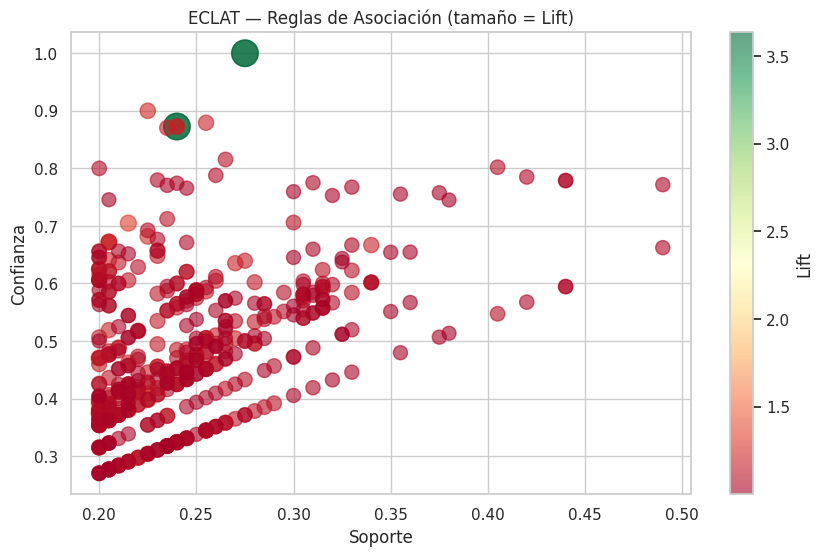

In [9]:
# Propósito: visualizar reglas con dispersión de soporte/confianza y tamaño por lift.
if not rules_df.empty:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        rules_df["support"],
        rules_df["confidence"],
        s=rules_df["lift"] * 100,
        alpha=0.6,
        c=rules_df["lift"],
        cmap="RdYlGn",
    )
    plt.colorbar(scatter, label="Lift")
    plt.xlabel("Soporte")
    plt.ylabel("Confianza")
    plt.title("ECLAT — Reglas de Asociación (tamaño = Lift)")
    plt.show()
else:
    print("No hay reglas para visualizar en scatter.")

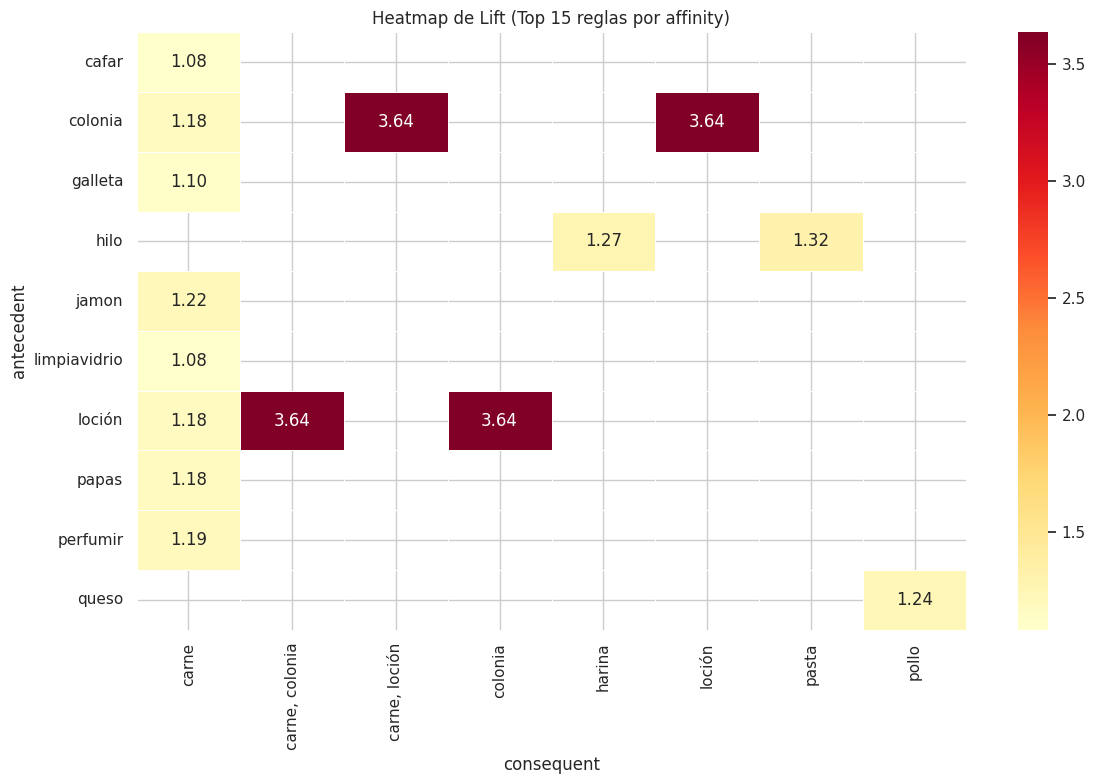

In [10]:
# Propósito: generar heatmap de lift para top reglas por affinity.
if not rules_df.empty:
    top_heat = rules_df.head(15)
    heat_df = top_heat.pivot_table(index='antecedent', columns='consequent', values='lift', aggfunc='mean')

    plt.figure(figsize=(12, 8))
    sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
    plt.title('Heatmap de Lift (Top 15 reglas por affinity)')
    plt.tight_layout()
    plt.show()
else:
    print('No hay reglas para visualizar en heatmap.')

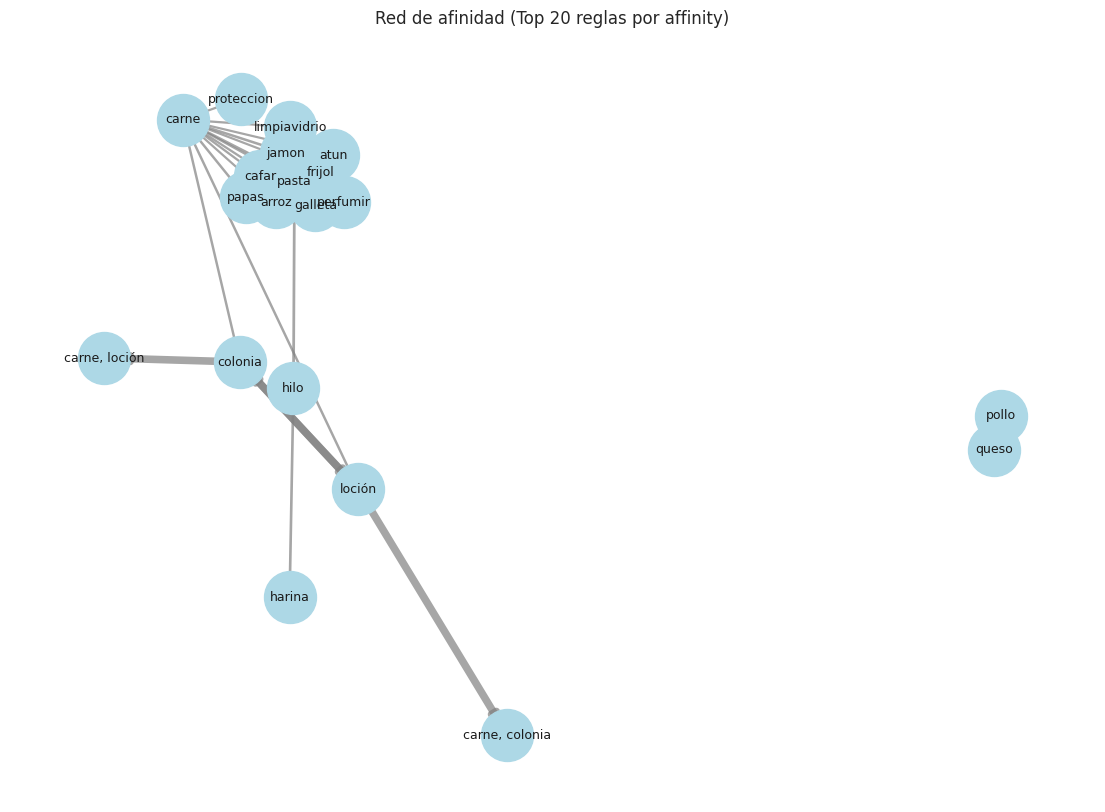

In [11]:
# Propósito: dibujar red de afinidad entre productos con pesos por lift.
if not rules_df.empty:
    top_net = rules_df.head(20)
    graph = nx.DiGraph()

    for _, row in top_net.iterrows():
        ant = row['antecedent']
        con = row['consequent']
        lift = row['lift']
        graph.add_edge(ant, con, weight=lift)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(graph, seed=42)
    widths = [graph[u][v]['weight'] * 1.5 for u, v in graph.edges()]
    nx.draw_networkx_nodes(graph, pos, node_size=1400, node_color='lightblue')
    nx.draw_networkx_labels(graph, pos, font_size=9)
    nx.draw_networkx_edges(graph, pos, width=widths, edge_color='gray', arrows=True, alpha=0.7)
    plt.title('Red de afinidad (Top 20 reglas por affinity)')
    plt.axis('off')
    plt.show()
else:
    print('No hay reglas para visualizar en red de afinidad.')

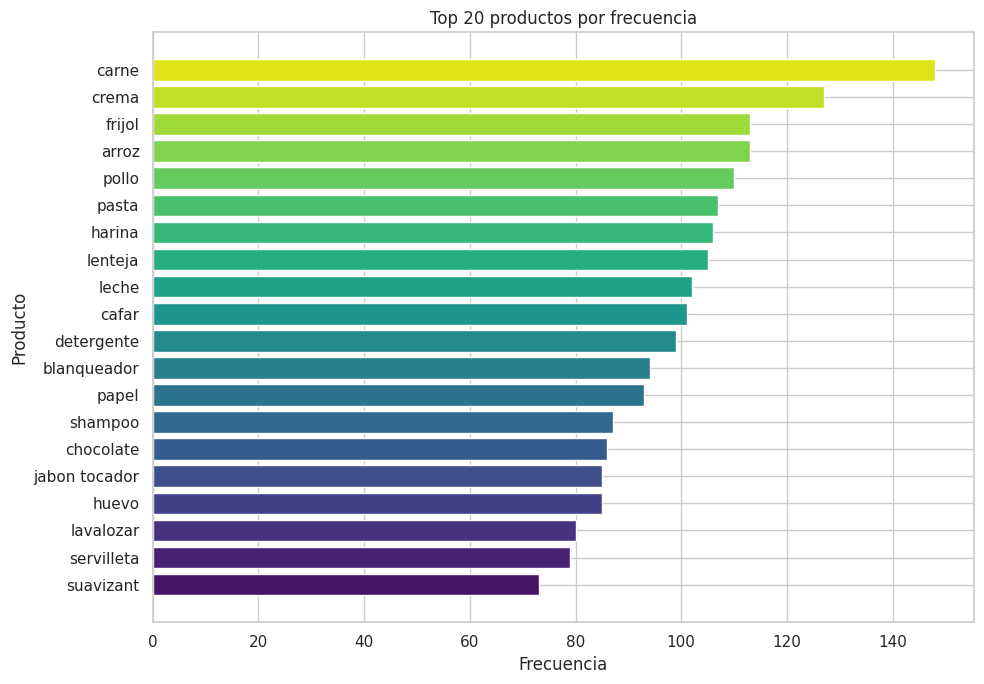

In [12]:
# Propósito: mostrar barras de frecuencia para top 20 productos.
product_freq = productos_df.sum().sort_values(ascending=False).head(20)
colors = sns.color_palette('viridis', n_colors=len(product_freq))

plt.figure(figsize=(10, 7))
plt.barh(product_freq.index[::-1], product_freq.values[::-1], color=colors)
plt.title('Top 20 productos por frecuencia')
plt.xlabel('Frecuencia')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

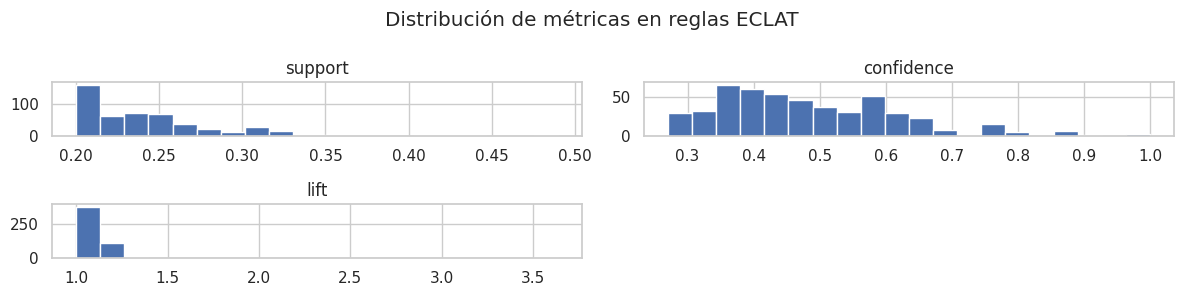

In [13]:
# Propósito: mostrar distribución de métricas de reglas (diagnóstico de calidad del modelo).
if not rules_df.empty:
    rules_df[['support', 'confidence', 'lift']].hist(figsize=(12, 3), bins=20)
    plt.suptitle('Distribución de métricas en reglas ECLAT')
    plt.tight_layout()
    plt.show()
else:
    print('No hay reglas para distribución de métricas.')

## 8. Segmentación por Estrato NSE

**Fase equivalente en `scripts/eclat.ipynb`:** función `eclat_segmento` y comparación por estrato.

En esta versión se estandariza el cálculo de soporte y la comparación se orienta a storytelling entre segmentos.


Estrato E1 | registros: 7


,itemset,support
0,frozenset({carne}),0.7143
1,frozenset({harina}),0.7143
2,frozenset({acondicionador}),0.5714
3,"frozenset({lavalozar, harina, carne})",0.5714
4,frozenset({lavalozar}),0.5714



Estrato E2 | registros: 50


,itemset,support
0,frozenset({carne}),0.72
1,frozenset({crema}),0.62
2,frozenset({arroz}),0.58
3,frozenset({pollo}),0.58
4,frozenset({leche}),0.54



Estrato E3 | registros: 95


,itemset,support
0,frozenset({carne}),0.7368
1,frozenset({crema}),0.6842
2,frozenset({arroz}),0.5895
3,frozenset({harina}),0.5895
4,frozenset({frijol}),0.5895



Estrato E4 | registros: 48


,itemset,support
0,frozenset({carne}),0.7708
1,frozenset({frijol}),0.6875
2,frozenset({blanqueador}),0.6250
3,frozenset({crema}),0.5833
4,"frozenset({frijol, carne})",0.5625


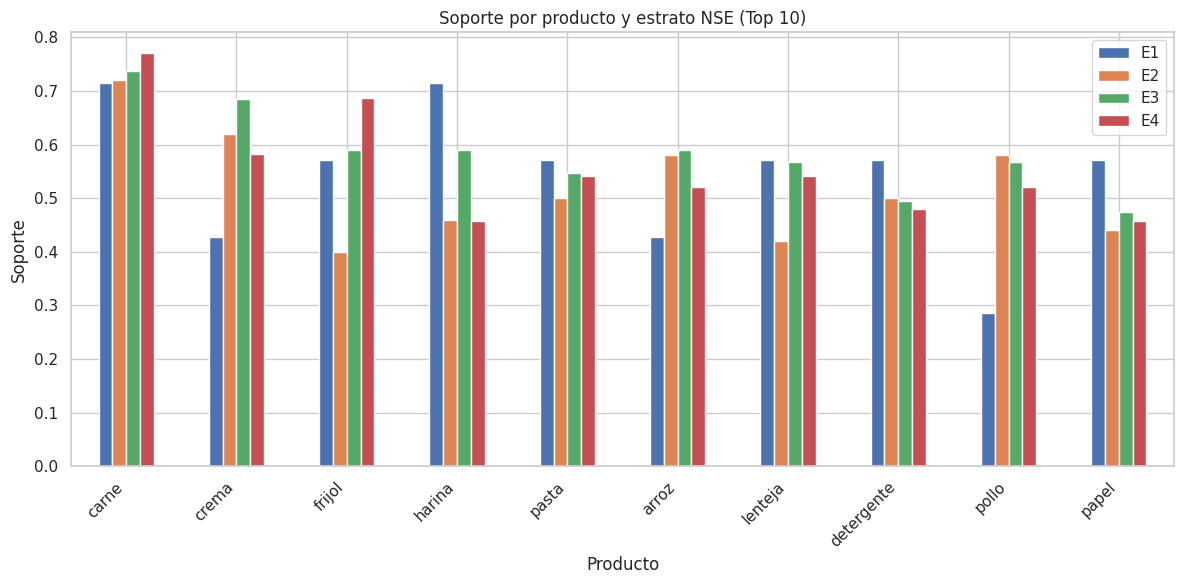

In [14]:
# Propósito: ejecutar ECLAT por estrato y construir comparativo de soporte por producto.
estrato_results: dict[str, pd.DataFrame] = {}
estrato_support_rows: list[pd.DataFrame] = []

for estrato in sorted(df_final['estrato_nse'].dropna().astype(str).unique()):
    subset = df_final[df_final['estrato_nse'].astype(str) == estrato]
    subset_freq, _, subset_products = run_eclat(subset, min_support=MIN_SUPPORT, max_len=MAX_ITEMSET)
    estrato_results[estrato] = subset_freq

    print(f'\nEstrato {estrato} | registros: {len(subset)}')
    display(subset_freq.head(5))

    product_support = (subset_products.sum() / max(len(subset_products), 1)).rename(estrato)
    estrato_support_rows.append(product_support.to_frame().T)

estrato_support_df = pd.concat(estrato_support_rows, axis=0).fillna(0)
common_top_10 = estrato_support_df.mean(axis=0).sort_values(ascending=False).head(10).index

estrato_plot_df = estrato_support_df[common_top_10].T
estrato_plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Soporte por producto y estrato NSE (Top 10)')
plt.xlabel('Producto')
plt.ylabel('Soporte')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Segmentación por Grupo de Edad

**Fase equivalente en `scripts/eclat.ipynb`:** segmentación por `grupo_edad` con `pd.cut`.

Objetivo: identificar diferencias de canasta por ciclo de vida para decisiones de surtido y comunicación.


Grupo Joven | registros: 194


,itemset,support
0,frozenset({carne}),0.7526
1,frozenset({crema}),0.6289
2,frozenset({frijol}),0.5722
3,frozenset({arroz}),0.5722
4,frozenset({harina}),0.5464



Grupo Adulto | registros: 1


,itemset,support
0,frozenset({acondicionador}),1.0
1,"frozenset({lavalozar, talco, carne})",1.0
2,"frozenset({lavalozar, suavizant, carne})",1.0
3,"frozenset({lavalozar, pollo, carne})",1.0
4,"frozenset({lavalozar, carne, pasta})",1.0



Grupo Adulto joven | registros: 5


,itemset,support
0,frozenset({blanqueador}),0.8
1,frozenset({crema}),0.8
2,frozenset({hilo}),0.8
3,"frozenset({hilo, crema})",0.8
4,frozenset({acondicionador}),0.6


Top productos por grupo etario:


,Joven,Adulto,Adulto joven
0,carne,acondicionador,blanqueador
1,crema,atun,crema
2,frijol,chocolate,hilo
3,arroz,carne,detergente
4,harina,cafar,chocolate
5,pollo,blanqueador,acondicionador
6,pasta,galleta,desinfectante
7,lenteja,huevo,papel
8,leche,detergente,leche
9,cafar,hilo,pollo


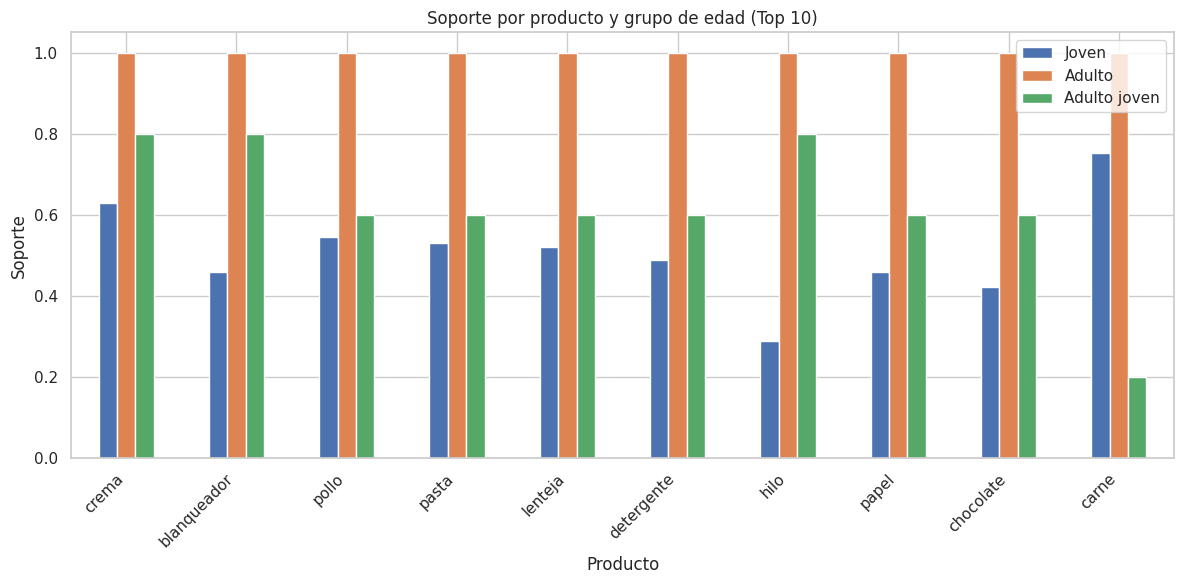

In [15]:
# Propósito: ejecutar ECLAT por grupo etario y comparar soportes de productos.
edad_results: dict[str, pd.DataFrame] = {}
edad_support_rows: list[pd.DataFrame] = []

for grupo in df_final['grupo_edad'].dropna().astype(str).unique():
    subset = df_final[df_final['grupo_edad'].astype(str) == grupo]
    subset_freq, _, subset_products = run_eclat(subset, min_support=MIN_SUPPORT, max_len=MAX_ITEMSET)
    edad_results[grupo] = subset_freq

    print(f'\nGrupo {grupo} | registros: {len(subset)}')
    display(subset_freq.head(5))

    product_support = (subset_products.sum() / max(len(subset_products), 1)).rename(grupo)
    edad_support_rows.append(product_support.to_frame().T)

edad_support_df = pd.concat(edad_support_rows, axis=0).fillna(0)
common_age_top_10 = edad_support_df.mean(axis=0).sort_values(ascending=False).head(10).index

top_por_grupo = {
    grupo: soportes.sort_values(ascending=False).head(10).index.tolist()
    for grupo, soportes in edad_support_df.iterrows()
}
print('Top productos por grupo etario:')
display(pd.DataFrame.from_dict(top_por_grupo, orient='index').T)

edad_plot_df = edad_support_df[common_age_top_10].T
edad_plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Soporte por producto y grupo de edad (Top 10)')
plt.xlabel('Producto')
plt.ylabel('Soporte')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Conclusiones

- El pipeline integra las fases observadas en `scripts/eclat.ipynb` (preparación, modelado, reglas, visualización, segmentación) en una narrativa única de presentación.
- La calidad de datos mejora con normalización lingüística, filtrado de ruido y separación estricta entre variables demográficas y productos.
- ECLAT se implementa con estructura vertical y `support_cache` O(1), evitando prácticas frágiles de búsqueda en DataFrame.
- La priorización combinada (`affinity` + `score`) facilita bajar hallazgos técnicos a decisiones comerciales.
- La segmentación por `estrato_nse` y `grupo_edad` habilita acciones diferenciadas de surtido, promoción y comunicación.

### Recomendaciones para siguiente iteración

1. Validar sensibilidad de resultados para distintos umbrales (`MIN_SUPPORT`, `MAX_ITEMSET`).
2. Curar `replace_map` con hallazgos de baja frecuencia para mejorar cobertura semántica.
3. Versionar una tabla final de "Top reglas accionables" por segmento para comité comercial.